In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import jax.numpy as jnp
from joblib import Parallel, delayed
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# Ensure your custom class is in the same directory or installed
from bilinear_lasso import bilinear_lasso

# --- Revised Configuration for Simulation ---
P, N_SUBJECTS = 264, 787
SPARSITY = 0.05    # 5% of beta elements will be non-zero
SNR = 2.0          # Signal-to-Noise Ratio
LAMBDA_GRID = [0.1,0.5,1,3,5,7,9]
N_SPLITS, N_JOBS = 5, 4
MAX_ITER, STEP_SIZE, TOL = 6000, 1e-6, 1e-5
DATA_DIR = "/Users/xue6bq/Desktop/Aiying/Data"

def generate_simulation_data(data_dir, p, n, sparsity, snr):
    """
    Generates synthetic data: y = diag(beta.T * X * beta) + noise
    """
    np.random.seed(42)
    
    # 1. Generate random design matrices X1 and X2 (p x p x n)
    z_rs = np.load(os.path.join(data_dir, "z_rs_raw.npy")).reshape((-1, p, p))
    z_emo = np.load(os.path.join(data_dir, "z_emo_raw.npy")).reshape((-1, p, p))
    X1 = jnp.array(np.transpose(z_rs, (1, 2, 0)))
    X2 = jnp.array(np.transpose(z_emo, (1, 2, 0)))
    
    # 2. Generate sparse ground-truth betas
    beta1_true = np.zeros((p, 1))
    beta2_true = np.zeros((p, 1))
    
    n_nonzero = int(p * sparsity)
    idx1 = np.random.choice(p, n_nonzero, replace=False)
    idx2 = np.random.choice(p, n_nonzero, replace=False)
    
    beta1_true[idx1] = np.random.uniform(0.5, 2.0, size=(n_nonzero, 1))
    beta2_true[idx2] = np.random.uniform(0.5, 2.0, size=(n_nonzero, 1))
    
    # 3. Generate y based on the bilinear model
    # Compute: y_i = beta1.T * X1_i * beta1 + beta2.T * X2_i * beta2
    def get_signal(X, b):
        # b is (p, 1), X is (p, p, n)
        b_flat = np.array(b).flatten()
        return np.einsum("i,ijk,j->k", b_flat, X, b_flat)
    
    
    signal = get_signal(X1, beta1_true) + get_signal(X2, beta2_true)
    
    # 4. Add noise based on SNR
    sigma = np.std(signal) / snr
    noise = np.random.normal(0, sigma, size=n)
    y = signal + noise
    
    return jnp.array(X1), jnp.array(X2), jnp.array(y), beta1_true, beta2_true

# --- Prediction and Evaluation remain largely the same ---
def predict_bilinear(X1, X2, beta1, beta2):
    b1 = np.array(beta1).flatten()
    b2 = np.array(beta2).flatten()
    return (np.einsum("i,ijk,j->k", b1, X1, b1) + 
            np.einsum("i,ijk,j->k", b2, X2, b2))

In [2]:
# --- Fix 1: Update evaluate_prediction to include 'corr' ---
def evaluate_prediction(y_true, y_pred):
    y_true_np = np.array(y_true).flatten()
    y_pred_np = np.array(y_pred).flatten()
    
    mse = np.mean((y_true_np - y_pred_np) ** 2)
    r2 = 1 - mse / np.var(y_true_np)
    # Add correlation to avoid the KeyError in run_one_cv_fold
    corr = np.corrcoef(y_true_np, y_pred_np)[0, 1] if np.var(y_pred_np) > 0 else 0
    
    return {"mse": float(mse), "r2": float(r2), "corr": float(corr)}

# --- Fix 2: Ensure you have an EBIC function defined ---
def calculate_ebic(mse, k, n, p, gamma=0.5):
    # Likelihood-based BIC variant for regression
    bic = n * np.log(mse) + k * np.log(n)
    ebic = bic + 2 * gamma * k * np.log(p)
    return bic, ebic

In [3]:
def run_one_cv_fold(X1, X2, y, train_idx, val_idx, lam, p, max_iter, step_size, tol):
    # 1. Split Data
    X1_tr, X1_val = X1[:, :, train_idx], X1[:, :, val_idx]
    X2_tr, X2_val = X2[:, :, train_idx], X2[:, :, val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # 2. Centering (Subtract mean, maintain scale/STD)
    y_m = y_tr.mean()
    y_tr_c, y_val_c = y_tr - y_m, y_val - y_m
    
    X1_m, X2_m = X1_tr.mean(axis=2, keepdims=True), X2_tr.mean(axis=2, keepdims=True)
    X1_tr_c, X1_val_c = X1_tr - X1_m, X1_val - X1_m
    X2_tr_c, X2_val_c = X2_tr - X2_m, X2_val - X2_m

    # 3. Fit Model on Training Set
    model = bilinear_lasso(X1_tr_c, X2_tr_c, y_tr_c, lam, lam)
    model.initialize_beta(jnp.zeros((p, 1)), jnp.zeros((p, 1)))
    model.fit(num_candidates=1, max_iter=max_iter, step_size=step_size, tol=tol)

    # 4. Extract Support
    # Using a small epsilon to catch non-zero coefficients
    supp1 = np.where(np.abs(np.array(model.beta1).flatten()) > 0.1)[0]
    supp2 = np.where(np.abs(np.array(model.beta2).flatten()) > 0.1)[0]
    n_features = len(supp1) + len(supp2)

    # 5. Training Evaluation (For BIC/EBIC)
    y_pred_tr = predict_bilinear(X1_tr_c, X2_tr_c, model.beta1, model.beta2)
    tr_mse = np.mean((np.array(y_tr_c) - y_pred_tr)**2)
    
    # Calculate BIC and EBIC (p*2 because we have two beta vectors of size p)
    bic, ebic = calculate_ebic(tr_mse, n_features, len(train_idx), p * 2)

    # 6. Validation Evaluation (For Prediction Performance)
    y_pred_val = predict_bilinear(X1_val_c, X2_val_c, model.beta1, model.beta2)
    metrics = evaluate_prediction(y_val_c, y_pred_val)
    
    return {
        "lambda": lam,
        "val_mse": metrics["mse"],
        "val_r2": metrics["r2"],
        "val_corr": metrics["corr"],
        "tr_mse": float(tr_mse),
        "bic": float(bic),
        "ebic": float(ebic),
        "supp1": supp1,
        "supp2": supp2,
        "n_features": n_features
    }

def run_one_lambda_cv(lam, X1, X2, y):
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=2026)
    
    # Run the folds
    folds = [run_one_cv_fold(X1, X2, y, tr, val, lam, P, MAX_ITER, STEP_SIZE, TOL) 
             for tr, val in kf.split(np.arange(y.shape[0]))]
    
    # Metrics extraction
    mse_list = [f["val_mse"] for f in folds]
    mean_mse = np.mean(mse_list)
    sd_mse = np.std(mse_list)
    
    # Aggregating Information Criteria
    mean_bic = np.mean([f["bic"] for f in folds])
    mean_ebic = np.mean([f["ebic"] for f in folds])
    
    # Stability: Lower is more consistent across folds
    cv_stability = sd_mse / mean_mse if mean_mse > 1e-9 else np.nan
    
    return {
        "lambda": lam,
        "mean_r2": np.mean([f["val_r2"] for f in folds]),
        "mean_mse": mean_mse,
        "sd_mse": sd_mse,
        "mean_bic": mean_bic,
        "mean_ebic": mean_ebic,
        "cv_stability": cv_stability, 
        "mean_features": np.mean([f["n_features"] for f in folds]),
        "folds": folds
    }

In [4]:
# 1. Generate Simulated Data
X1, X2, y, b1_true, b2_true = generate_simulation_data(DATA_DIR, P, N_SUBJECTS, SPARSITY, SNR)
X1_m, X2_m = X1.mean(axis=2, keepdims=True), X2.mean(axis=2, keepdims=True)
X1, X2 = X1 - X1_m, X2 - X2_m
y = y - y.mean()

(array([  1.,  29.,  94., 177., 197., 159.,  75.,  31.,  15.,   9.]),
 array([-202.51225791, -158.25455763, -113.99685735,  -69.73915707,
         -25.48145679,   18.77624349,   63.03394378,  107.29164406,
         151.54934434,  195.80704462,  240.0647449 ]),
 <BarContainer object of 10 artists>)

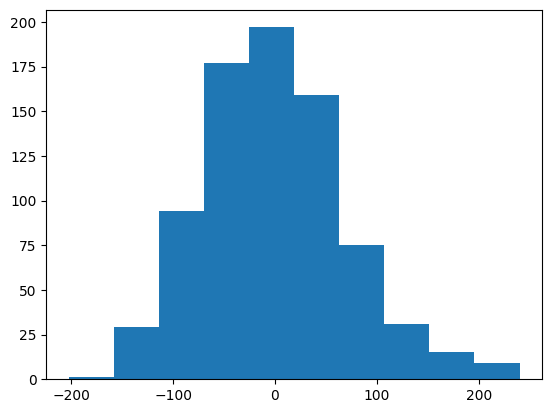

In [5]:
plt.hist(predict_bilinear(X1, X2, b1_true, b2_true))

In [6]:

# 2. Run the Parallel CV (Using your existing run_one_lambda_cv function)
# Note: Ensure bilinear_lasso is imported correctly as in your snippet
results = Parallel(n_jobs=N_JOBS)(
    delayed(run_one_lambda_cv)(l, X1, X2, y) for l in LAMBDA_GRID
)

# 3. Process Results
summary_data = []
for r in results:
    # Calculate Support Recovery (True Positive Rate) for the first fold as an example
    # Or average over folds
    found_supp1 = set(r['folds'][0]['supp1'])
    true_supp1 = set(np.where(np.abs(b1_true.flatten()) > 0)[0])
    tpr = len(found_supp1.intersection(true_supp1)) / len(true_supp1) if len(true_supp1) > 0 else 0

    summary_data.append({
        "lambda": r["lambda"],
        "Test R2": r["mean_r2"],
        "Avg Features": r["mean_features"],
        "EBIC": r["mean_ebic"],
        "Stability": r["cv_stability"],
        "True Positive Rate": tpr
    })

summary_df = pd.DataFrame(summary_data).sort_values("EBIC")
print("\n--- Simulation Results ---")
print(summary_df)

0 th try
initialized loss: 5715.80859375


  0%|          | 15/6000 [00:01<07:48, 12.78it/s]

0 th try
initialized loss: 5719.3408203125


  0%|          | 10/6000 [00:01<11:56,  8.36it/s] 

0 th try
initialized loss: 6014.12548828125


...

 97%|█████████▋| 5802/6000 [10:09<00:15, 12.78it/s]

Job took:  626.3765659332275
Final loss: 1254.7939453125
Final loss: 1254.7939453125


100%|█████████▉| 5998/6000 [10:21<00:00, 16.98it/s]

Job took:  621.5973680019379
Final loss: 1334.66259765625
Final loss: 1334.66259765625

--- Simulation Results ---
   lambda   Test R2  Avg Features         EBIC  Stability  True Positive Rate
6     9.0  0.781866          63.2  5136.447380   0.137598            0.615385
5     7.0  0.772385          78.8  5292.999821   0.114594            0.615385
4     5.0  0.747912         111.0  5605.004084   0.071526            0.461538
3     3.0  0.686103         179.6  6291.634736   0.039265            0.615385
2     1.0  0.543786         344.0  8002.483449   0.092315            0.769231
1     0.5  0.406159         423.0  8862.686802   0.055503            0.769231
0     0.1  0.288565         480.2  9540.821827   0.087755            0.923077


100%|██████████| 6000/6000 [10:21<00:00,  9.65it/s]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_simulation_diagnostics(results_df, b1_true, b2_true, final_model, X1, X2, y_true):
    """
    Generates a comprehensive diagnostic dashboard for the bilinear simulation.
    """
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.3)

    # 1. Prediction Performance Path
    ax1 = fig.add_subplot(gs[0, 0])
    sns.lineplot(data=results_df, x='lambda', y='Test R2', marker='o', ax=ax1, color='royalblue')
    ax1.set_title("Validation $R^2$ vs $\lambda$", fontweight='bold')
    ax1.set_ylabel("Mean $R^2$")

    # 2. Information Criterion (Model Selection)
    ax2 = fig.add_subplot(gs[0, 1])
    sns.lineplot(data=results_df, x='lambda', y='EBIC', marker='s', ax=ax2, color='crimson')
    ax2.set_title("EBIC vs $\lambda$ (Model Selection)", fontweight='bold')
    ax2.set_ylabel("EBIC (Lower is Better)")

    # 3. Model Complexity
    ax3 = fig.add_subplot(gs[0, 2])
    sns.lineplot(data=results_df, x='lambda', y='Avg Features', marker='^', ax=ax3, color='forestgreen')
    ax3.set_title("Sparsity: Features vs $\lambda$", fontweight='bold')
    ax3.set_ylabel("Number of Non-zero Coeffs")

    # 4. Support Recovery: Beta 1 (Resting State)
    ax4 = fig.add_subplot(gs[1, :])
    true_idx1 = np.where(b1_true.flatten() != 0)[0]
    est_b1 = np.array(final_model.beta1).flatten()
    ax4.stem(true_idx1, b1_true.flatten()[true_idx1], linefmt='C0-', markerfmt='C0o', label='Ground Truth', basefmt=" ")
    ax4.stem(np.arange(len(est_b1)), est_b1, linefmt='C1--', markerfmt='C1x', label='Estimated', basefmt=" ")
    ax4.set_title("Recovery of $\\beta_1$ (Resting State)", fontweight='bold')
    ax4.legend()

    # 5. Support Recovery: Beta 2 (Emotional Task)
    ax5 = fig.add_subplot(gs[2, 0:2])
    true_idx2 = np.where(b2_true.flatten() != 0)[0]
    est_b2 = np.array(final_model.beta2).flatten()
    ax5.stem(true_idx2, b2_true.flatten()[true_idx2], linefmt='C2-', markerfmt='C2o', label='Ground Truth', basefmt=" ")
    ax5.stem(np.arange(len(est_b2)), est_b2, linefmt='C3--', markerfmt='C3x', label='Estimated', basefmt=" ")
    ax5.set_title("Recovery of $\\beta_2$ (Emotional Task)", fontweight='bold')
    ax5.legend()

    # 6. Final Prediction Scatter
    ax6 = fig.add_subplot(gs[2, 2])
    y_pred = (np.einsum("i,ijk,j->k", est_b1, X1, est_b1) + 
              np.einsum("i,ijk,j->k", est_b2, X2, est_b2))
    ax6.scatter(y_true, y_pred, alpha=0.4, s=20, color='purple')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax6.plot(lims, lims, 'k--', alpha=0.6)
    ax6.set_xlabel("Ground Truth Signal")
    ax6.set_ylabel("Model Prediction")
    ax6.set_title("Subject-level Accuracy", fontweight='bold')

    plt.show()

# --- Example Usage ---
# 1. Convert results list to a DataFrame
results_df = pd.DataFrame(results)

# 2. Identify the optimal lambda (minimum EBIC)
best_lambda = results_df.loc[results_df['mean_ebic'].idxmin(), 'lambda']
print(f"Optimal Lambda: {best_lambda}")


<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/var/folders/ds/hzlmym6914z94tg39pt41n280000gs/T/ipykernel_74653/884484331.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title("Validation $R^2$ vs $\lambda$", fontweight='bold')
/var/folders/ds/hzlmym6914z94tg39pt41n280000gs/T/ipykernel_74653/884484331.py:22: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_title("EBIC vs $\lambda$ (Model Selection)", fontweight='bold')
/var/folders/ds/hzlmym6914z94tg39pt41n280000gs/T/ipykernel_74653/884484331.py:28: SyntaxWarning: invalid escape sequence '\l'
  ax3.set_title("Sparsity: Features vs $\lambda$", fontweight='bold')


Optimal Lambda: 9.0


209
6.00411
222
4.6769505
0 th try
initialized loss: 22395.654296875


100%|██████████| 6000/6000 [07:24<00:00, 13.50it/s]

Job took:  444.52073407173157
Final loss: 1212.6866455078125
Final loss: 1212.6866455078125


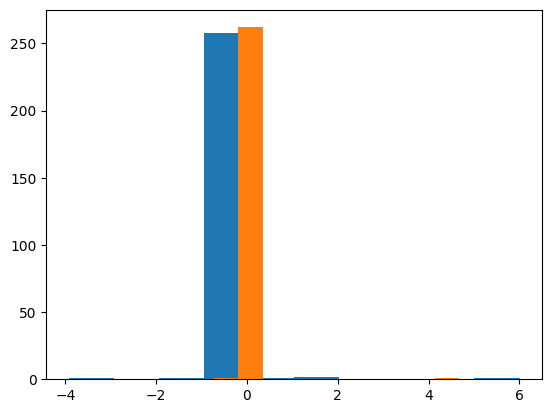

In [8]:
import cvxpy as cp
def initial_Beta(X, y, l=1):
    p = X.shape[0]
    n = X.shape[2]

    # Run the sdp solving process
    B = cp.Variable((p, p), symmetric = True)  # symmetric
    mu = 1
    residuals = [cp.trace(X[:,:,i] @ B) - y[i] for i in range(n)]
    objective = cp.Minimize(cp.sum_squares(cp.vstack(residuals))/(2*n) + l * cp.normNuc(B))

    problem = cp.Problem(objective)
    problem.solve(verbose=False)

    print(jnp.linalg.matrix_rank(B.value))

    eigvals, eigvecs = jnp.linalg.eigh(B.value)
    plt.hist(eigvals)
    # v = (jnp.sqrt(eigvals[-1]) * eigvecs[:, -1]).reshape(-1,1)

    idx = jnp.argmax(jnp.abs(eigvals))
    lambda_max_abs = eigvals[idx]
    v = (jnp.sqrt(jnp.abs(lambda_max_abs)) * eigvecs[:, idx]).reshape(-1, 1)
    v = v * jnp.sign(v[0])
    print(lambda_max_abs)
    return v

v1 = initial_Beta(X1, y, 20)
v2 = initial_Beta(X2, y, 20)

best_lambda = 6

# 3. Retrain the Final Model on the ENTIRE dataset
# This is your "Best Model" to be used for inference or reporting
final_model = bilinear_lasso(X1, X2, y, best_lambda, best_lambda)
# final_model.initialize_beta(jnp.zeros((P, 1)), jnp.zeros((P, 1)))
final_model.initialize_beta(v1, v2)
final_model.fit(num_candidates=1, max_iter=MAX_ITER, step_size=STEP_SIZE, tol=TOL)


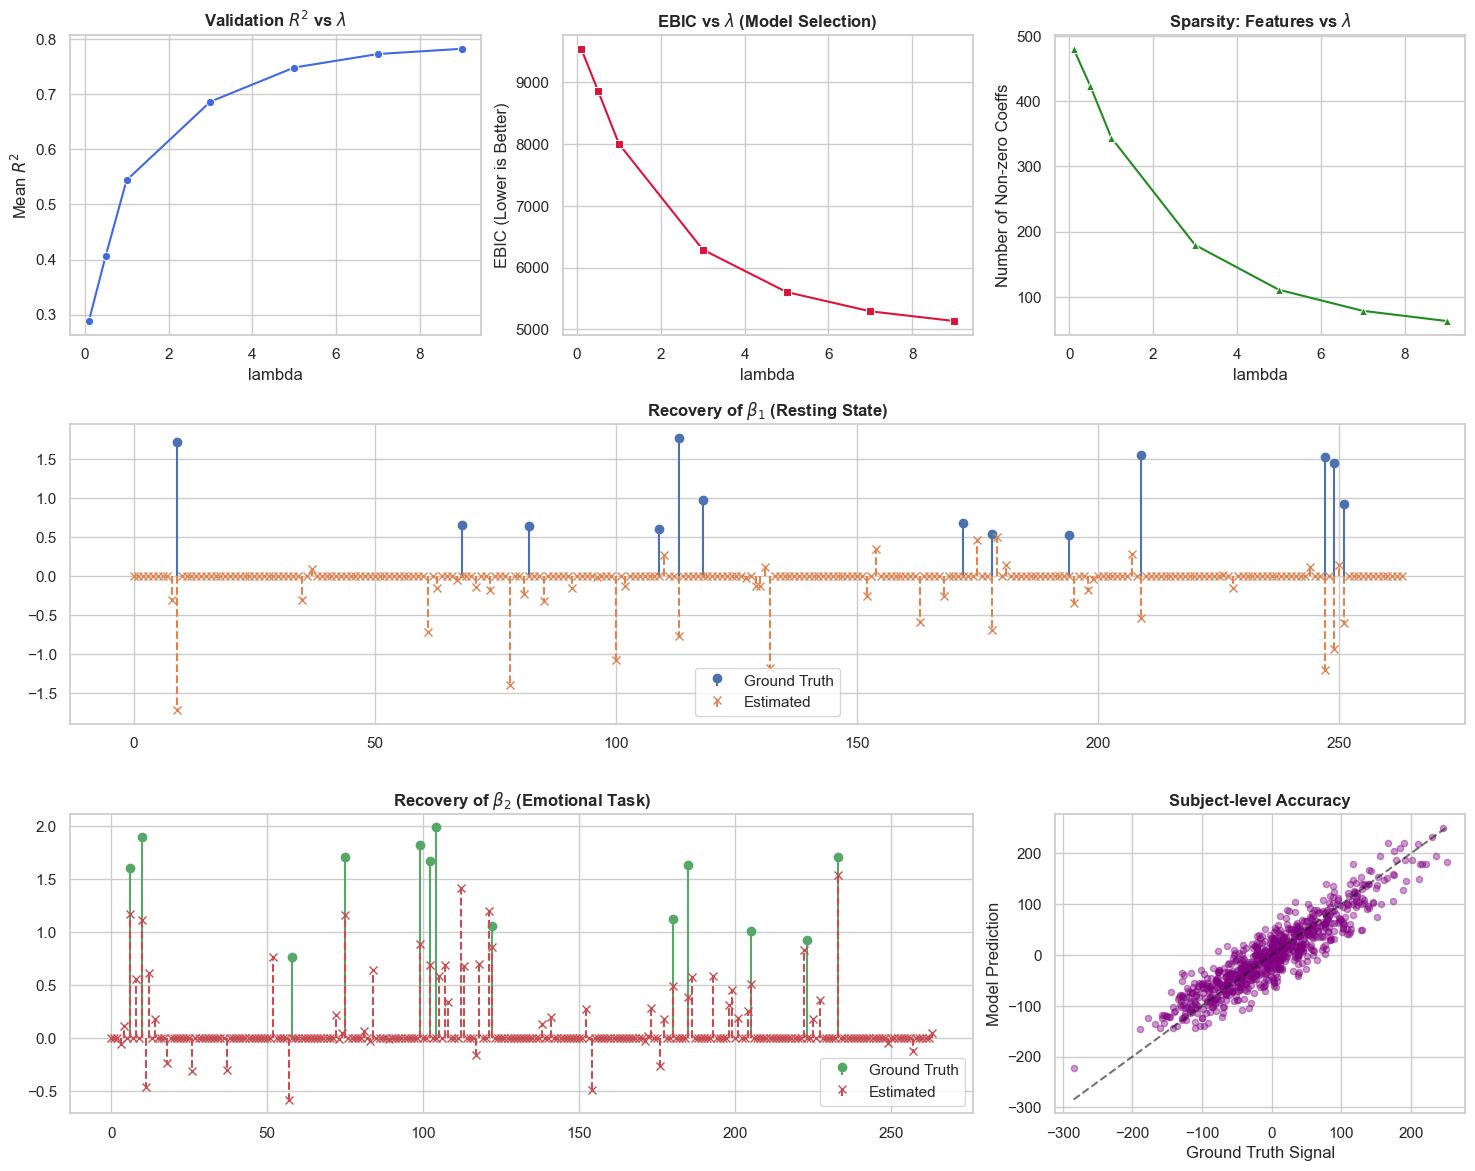

In [9]:
plot_simulation_diagnostics(summary_df, b1_true, b2_true, final_model, X1, X2, y)

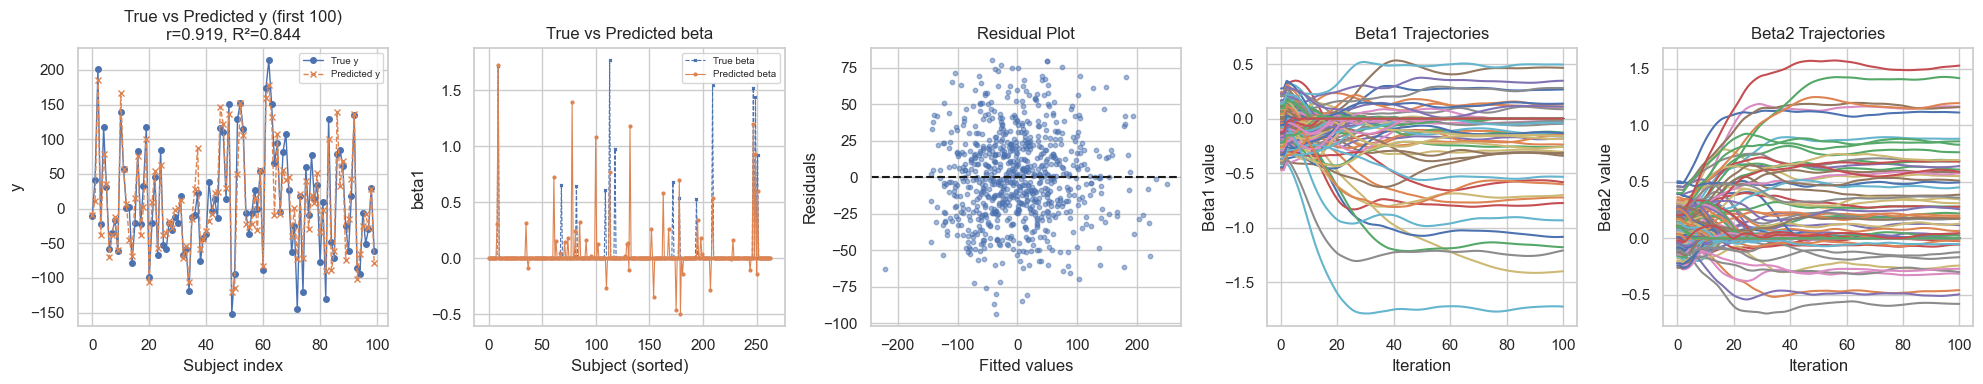

In [10]:
y_true = np.array(y)
y_hat = (np.einsum('ij,ijk,ji->k', final_model.beta1, np.array(X1), final_model.beta1) +
         np.einsum('ij,ijk,ji->k', final_model.beta2, np.array(X2), final_model.beta2))
residuals = y_true - y_hat

corr = np.corrcoef(y_true, y_hat)[0, 1]
r2   = 1 - np.var(residuals) / np.var(y_true)

beta1_traj = np.array(final_model.trajectory[final_model.sel_idx]['beta1'])  # (num_steps, p, 1)
beta2_traj = np.array(final_model.trajectory[final_model.sel_idx]['beta2'])  # (num_steps, p, 1)


def align_sign(beta_hat, beta_true):
    if jnp.dot(beta_hat.flatten(), beta_true.flatten()) < 0:
        return -beta_hat
    return beta_hat


plt.figure(figsize=(20, 4))

# Panel 1: First 50 subjects, line+dot style
plt.subplot(1, 5, 1)
plt.plot(y_true[:100], 'o-', markersize=4, linewidth=1, label='True y')
plt.plot(y_hat[:100],  'x--', markersize=4, linewidth=1, label='Predicted y')
plt.title(f'True vs Predicted y (first 100)\nr={corr:.3f}, R²={r2:.3f}')
plt.xlabel('Subject index')
plt.ylabel('y')
plt.legend(fontsize=7)
plt.grid(True)

# Panel 2: Sorted by true y — predicted first (behind), true on top
plt.subplot(1, 5, 2)
# idx = np.argsort(y_true)
plt.plot(b1_true,  'x--', markersize=2, linewidth=0.8, label='True beta')
plt.plot(align_sign(final_model.beta1, b1_true), 'o-',  markersize=2, linewidth=0.8, label='Predicted beta')
plt.title('True vs Predicted beta')
plt.xlabel('Subject (sorted)')
plt.ylabel('beta1')
plt.legend(fontsize=7)
plt.grid(True)

# Panel 3: Residual plot
plt.subplot(1, 5, 3)
plt.scatter(y_hat, residuals, s=10, alpha=0.5)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residual Plot')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True)

# Panel 4: Beta1 trajectories (first 5 components)
plt.subplot(1, 5, 4)
for i in range(beta1_traj.shape[1]):
    plt.plot(beta1_traj[:, i, 0], label=f'beta1[{i}]')
plt.title('Beta1 Trajectories')
plt.xlabel('Iteration')
plt.ylabel('Beta1 value')
plt.grid(True)

# Panel 5: Beta2 trajectories (first 5 components)
plt.subplot(1, 5, 5)
for i in range(beta2_traj.shape[1]):
    plt.plot(beta2_traj[:, i], label=f'beta2[{i}]')
plt.title('Beta2 Trajectories')
plt.xlabel('Iteration')
plt.ylabel('Beta2 value')
plt.grid(True)

plt.tight_layout()
plt.show()

(array([  1.,   1.,   3.,   1.,   3.,   3.,   9., 233.,   6.,   4.]),
 array([-1.72338283, -1.50157976, -1.27977669, -1.05797362, -0.83617055,
        -0.61436749, -0.39256442, -0.17076135,  0.05104172,  0.27284479,
         0.4946478 ]),
 <BarContainer object of 10 artists>)

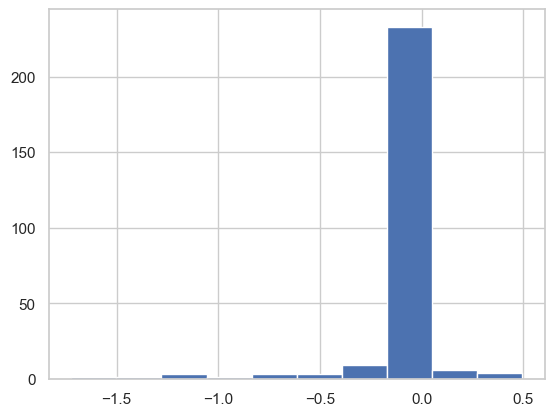

In [11]:
plt.hist(final_model.beta1)

(array([ 2.,  7., 16., 45., 55., 57., 39., 32.,  8.,  3.]),
 array([-0.434578  , -0.36986664, -0.30515528, -0.24044389, -0.17573252,
        -0.11102116, -0.04630977,  0.01840159,  0.08311296,  0.14782435,
         0.21253566]),
 <BarContainer object of 10 artists>)

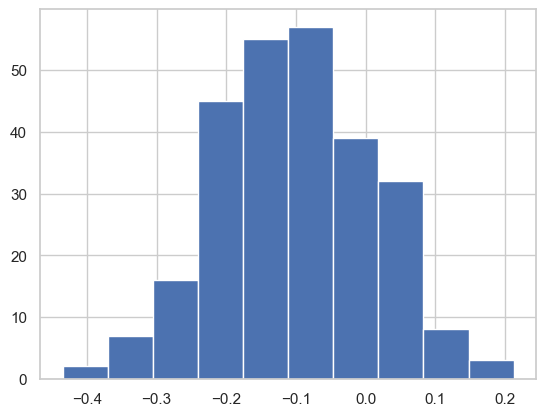

In [12]:
plt.hist(v1)

(array([ 7., 19., 38., 49., 56., 39., 25., 17., 10.,  4.]),
 array([-0.14692208, -0.09476186, -0.04260163,  0.00955859,  0.06171882,
         0.11387905,  0.16603926,  0.21819949,  0.27035972,  0.32251996,
         0.37468016]),
 <BarContainer object of 10 artists>)

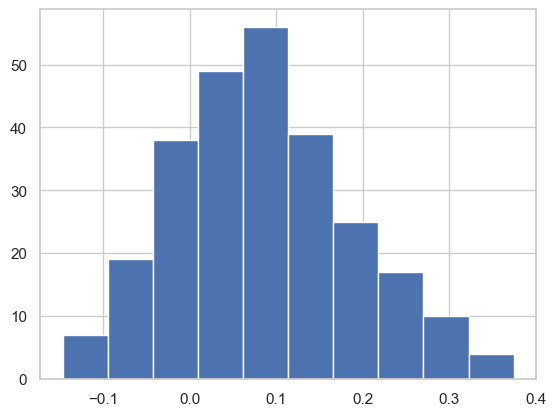

In [13]:
plt.hist(v2)

In [14]:
X1[:,:,0]

Array([[0.        , 0.06180668, 0.27889442, ..., 0.20336735, 0.1789293 ,
        0.12584496],
       [0.06180668, 0.        , 0.13441989, ..., 0.31102008, 0.22615343,
        0.09704891],
       [0.27889442, 0.13441989, 0.        , ..., 0.05573899, 0.257714  ,
        0.23563308],
       ...,
       [0.20336735, 0.31102008, 0.05573899, ..., 0.        , 0.30585897,
        0.15701336],
       [0.1789293 , 0.22615343, 0.257714  , ..., 0.30585897, 0.        ,
        0.22320801],
       [0.12584496, 0.09704891, 0.23563308, ..., 0.15701336, 0.22320801,
        0.        ]], dtype=float32)

In [21]:
import os
import pandas as pd
import numpy as np

# 1. Setup the directory
save_dir = "/Users/xue6bq/Desktop/real_data/simulation"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# --- A. Save the Summary Table ---
# This is the small table (usually 10-20 rows) with your CV averages
summary_df.to_csv(os.path.join(save_dir, "simulation_summary.csv"), index=False)

# --- B. Save Ground Truth & Estimated Weights ---
# You still need these for the stem plots (the most important part of the viz)
np.save(os.path.join(save_dir, "beta1_true.npy"), np.array(b1_true))
np.save(os.path.join(save_dir, "beta2_true.npy"), np.array(b2_true))
np.save(os.path.join(save_dir, "beta1_estimated.npy"), np.array(final_model.beta1))
np.save(os.path.join(save_dir, "beta2_estimated.npy"), np.array(final_model.beta2))
np.save(os.path.join(save_dir, "y_true.npy"), np.array(y))

print(f"✅ Summary and weights exported to: {save_dir}")

✅ Summary and weights exported to: /Users/xue6bq/Desktop/real_data/simulation


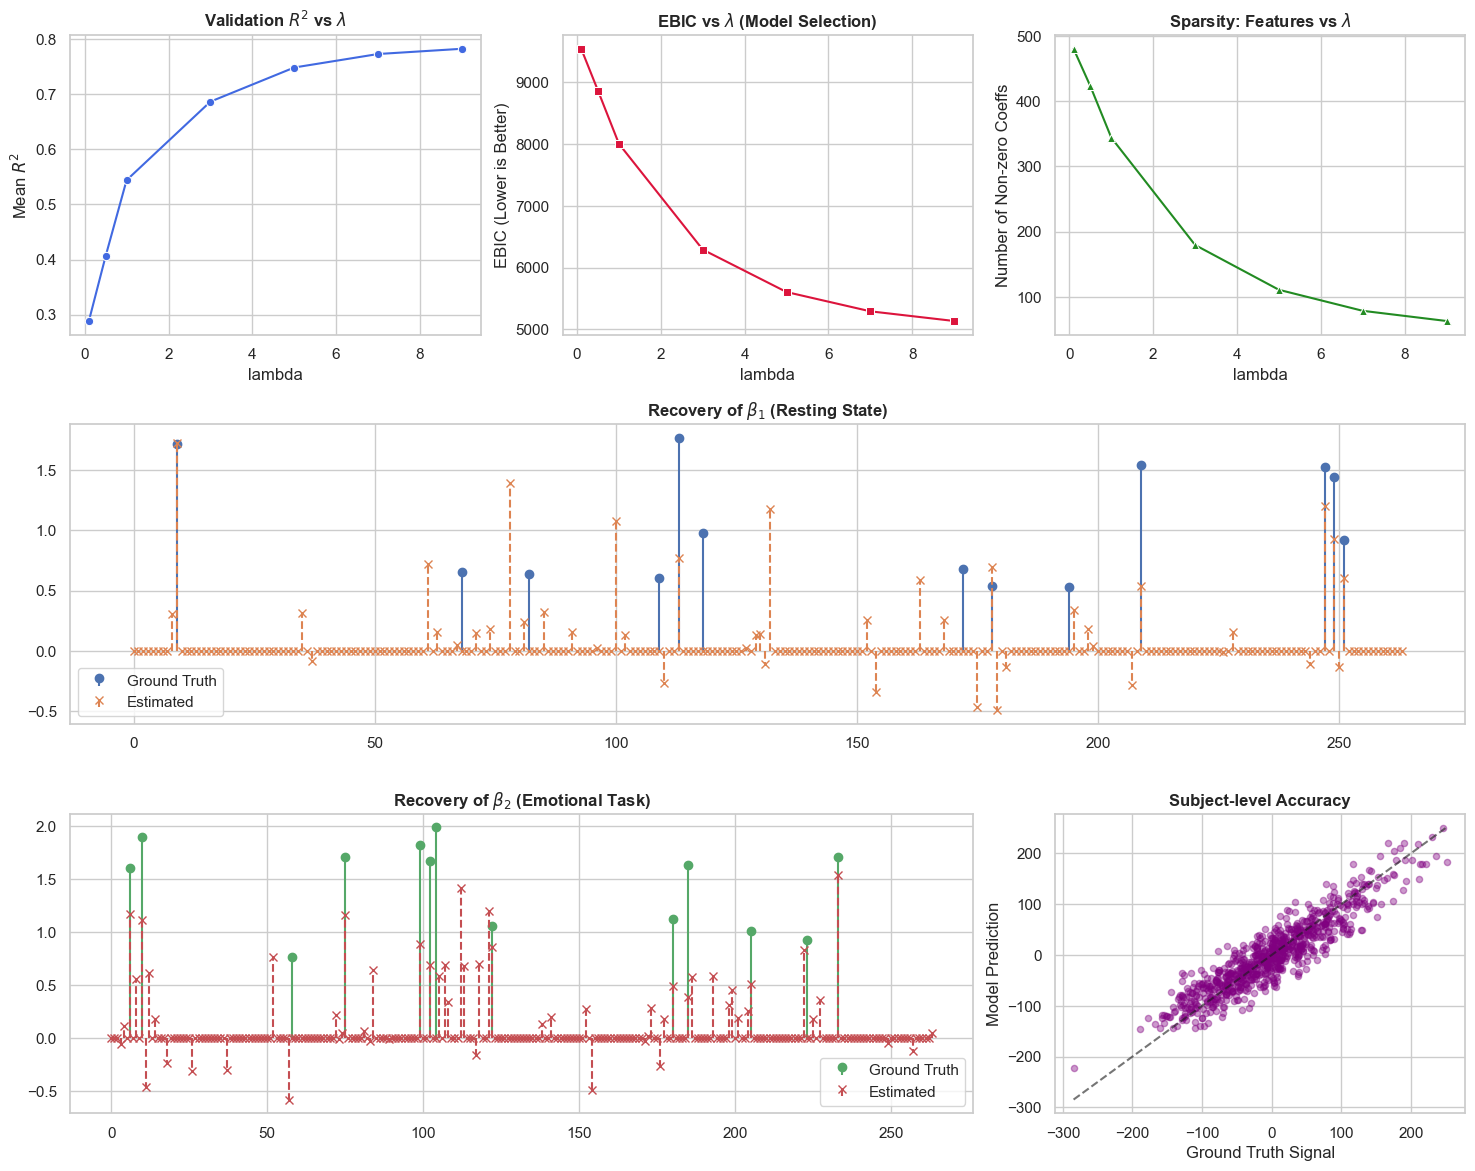

In [25]:
import pandas as pd
import numpy as np
import os

# Define path
save_dir = "/Users/xue6bq/Desktop/real_data/simulation/"

# Load the data
summary_df = pd.read_csv(os.path.join(save_dir, "simulation_summary.csv"))
b1_true = np.load(os.path.join(save_dir, "beta1_true.npy"))
b2_true = np.load(os.path.join(save_dir, "beta2_true.npy"))
b1_est  = align_sign(np.load(os.path.join(save_dir, "beta1_estimated.npy")), b1_true)
b2_est  = align_sign(np.load(os.path.join(save_dir, "beta2_estimated.npy")), b2_true)
y_true  = np.load(os.path.join(save_dir, "y_true.npy"))

# Lightweight model wrapper
class ModelWrapper:
    def __init__(self, b1, b2):
        self.beta1 = b1
        self.beta2 = b2

loaded_model = ModelWrapper(b1_est, b2_est)

# Call the plotting function
# We use summary_df for 'results_df' because it contains the 'lambda' and 'mean_ebic' columns
plot_simulation_diagnostics(
    results_df=summary_df, 
    b1_true=b1_true, 
    b2_true=b2_true, 
    final_model=loaded_model, 
    X1=X1, # Ensure X1 and X2 are in your environment
    X2=X2, 
    y_true=y_true
)

In [19]:
summary_df

,lambda,Test R2,Avg Features,EBIC,Stability,True Positive Rate
6,9.0,0.781866,63.2,5136.447380,0.137598,0.615385
5,7.0,0.772385,78.8,5292.999821,0.114594,0.615385
4,5.0,0.747912,111.0,5605.004084,0.071526,0.461538
3,3.0,0.686103,179.6,6291.634736,0.039265,0.615385
2,1.0,0.543786,344.0,8002.483449,0.092315,0.769231
1,0.5,0.406159,423.0,8862.686802,0.055503,0.769231
0,0.1,0.288565,480.2,9540.821827,0.087755,0.923077


In [20]:
results_df

,lambda,mean_r2,mean_mse,sd_mse,mean_bic,mean_ebic,cv_stability,mean_features,folds
0,0.1,0.288565,4303.471240,377.651277,6530.401791,9540.821827,0.087755,480.2,"[{'lambda': 0.1, 'val_mse': 3857.091064453125,..."
1,0.5,0.406159,3595.140723,199.541218,6210.859074,8862.686802,0.055503,423.0,"[{'lambda': 0.5, 'val_mse': 3413.818115234375,..."
2,1.0,0.543786,2754.077490,254.243690,5845.914327,8002.483449,0.092315,344.0,"[{'lambda': 1, 'val_mse': 2309.490234375, 'val..."
3,3.0,0.686103,1895.556738,74.428474,5165.705044,6291.634736,0.039265,179.6,"[{'lambda': 3, 'val_mse': 1807.9434814453125, ..."
4,5.0,0.747912,1516.646680,108.479016,4909.134396,5605.004084,0.071526,111.0,"[{'lambda': 5, 'val_mse': 1368.866455078125, '..."
5,7.0,0.772385,1368.371924,156.806983,4798.995034,5292.999821,0.114594,78.8,"[{'lambda': 7, 'val_mse': 1141.532470703125, '..."
6,9.0,0.781866,1312.594092,180.609939,4740.240495,5136.447380,0.137598,63.2,"[{'lambda': 9, 'val_mse': 1052.9365234375, 'va..."
